<a href="https://colab.research.google.com/github/jhmelomo/ucv-ate-si-lab13-manuscritos/blob/main/Laboratorio_UCV_CNN_Digitos_UCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD CÉSAR VALLEJO
## Escuela Profesional de Ingeniería de Sistemas

# LABORATORIO COMPLETO
## Clasificación de dígitos escritos a mano usando CNN

**Curso:** Sistemas Inteligentes  
**Unidad:** Tercera unidad  
**Tema:** Redes Neuronales Convolucionales  
**Duración sugerida:** 1 sesión de laboratorio + trabajo autónomo  
**Herramientas:** Python, Jupyter Notebook, TensorFlow/Keras, Scikit-Learn, Matplotlib y UCI Machine Learning Repository  
**Producto final:** Modelo CNN capaz de reconocer dígitos escritos a mano del 0 al 9.


## 1. Presentación del laboratorio

En este laboratorio el estudiante construirá una **Red Neuronal Convolucional (CNN)** para clasificar imágenes pequeñas de dígitos escritos a mano.

El objetivo es comprender cómo una CNN puede detectar patrones visuales mediante filtros, convoluciones, pooling y capas densas.


## 2. Resultado de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

- Cargar un dataset real desde UCI Machine Learning Repository.
- Representar datos tabulares como imágenes de 8x8 píxeles.
- Construir una CNN básica con TensorFlow/Keras.
- Entrenar y evaluar un modelo de clasificación multiclase.
- Interpretar matriz de confusión y predicciones individuales.
- Comparar una CNN con una red neuronal tradicional.


## 3. Contexto del caso

Una organización desea implementar un pequeño sistema OCR para reconocer números escritos a mano. Este tipo de solución puede utilizarse en digitalización de formularios, reconocimiento de códigos, lectura automática de documentos o sistemas educativos.

El sistema debe recibir una imagen de un dígito y clasificarla como uno de los valores posibles:

```text
0, 1, 2, 3, 4, 5, 6, 7, 8 o 9
```


## 4. Arquitectura conceptual

Una CNN procesa una imagen de forma diferente a una red neuronal densa. En lugar de analizar todos los píxeles como variables independientes, utiliza filtros para detectar patrones locales.

```text
Imagen 8x8
   ↓
Convolución
   ↓
Pooling
   ↓
Flatten
   ↓
Dense
   ↓
Clasificación 0-9
```


## 5. Preparación del entorno

Ejecute esta celda si trabaja en Google Colab o en un entorno local sin las librerías instaladas.


In [1]:
%pip install ucimlrepo tensorflow pandas numpy matplotlib scikit-learn -q

## 6. Importar librerías


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## 7. Cargar dataset real desde UCI

Se utilizará el dataset **Optical Recognition of Handwritten Digits** de UCI Machine Learning Repository.

Cada registro contiene 64 valores, que representan una imagen de **8x8 píxeles**. La etiqueta indica el dígito correspondiente entre 0 y 9.


In [3]:
digits = fetch_ucirepo(id=80)

X = digits.data.features
y = digits.data.targets.squeeze()

print('Dimensión de X:', X.shape)
print('Dimensión de y:', y.shape)

X.head()

Dimensión de X: (5620, 64)
Dimensión de y: (5620,)


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,0,6,14,7,1,0,0
1,0,0,10,16,6,0,0,0,0,7,...,3,0,0,0,10,16,15,3,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,0,9,14,0,0,0,0
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,0,1,15,2,0,0
4,0,0,5,14,4,0,0,0,0,0,...,12,0,0,0,4,12,14,7,0,0


## 8. Exploración inicial


In [4]:
print('Clases disponibles:', sorted(y.unique()))
print('\nDistribución de clases:')
print(y.value_counts().sort_index())

Clases disponibles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Distribución de clases:
class
0    554
1    571
2    557
3    572
4    568
5    558
6    558
7    566
8    554
9    562
Name: count, dtype: int64


## 9. Convertir los datos a imágenes 8x8

Una CNN espera datos con forma:

```text
(cantidad_imágenes, alto, ancho, canales)
```

Como las imágenes son en escala de grises, se utiliza un solo canal.


In [5]:
X_images = X.to_numpy().reshape(-1, 8, 8, 1)
y_values = y.to_numpy().astype('int')

print('Nueva forma de X:', X_images.shape)
print('Forma de y:', y_values.shape)

Nueva forma de X: (5620, 8, 8, 1)
Forma de y: (5620,)


## 10. Visualizar ejemplos del dataset


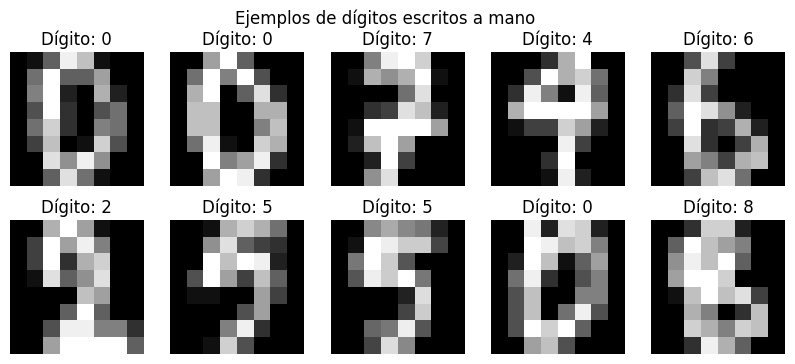

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_images[i].reshape(8, 8), cmap='gray')
    plt.title(f'Dígito: {y_values[i]}')
    plt.axis('off')

plt.suptitle('Ejemplos de dígitos escritos a mano')
plt.show()

## 11. Normalización

Los valores de los píxeles van de 0 a 16. Para entrenar mejor la red neuronal, se normalizan entre 0 y 1.


In [7]:
X_images = X_images / 16.0

print('Valor mínimo:', X_images.min())
print('Valor máximo:', X_images.max())

Valor mínimo: 0.0
Valor máximo: 1.0


## 12. Codificación de la variable objetivo

Como es un problema multiclase, convertimos las etiquetas en formato one-hot.


In [8]:
num_classes = 10
y_categorical = to_categorical(y_values, num_classes=num_classes)

print('Ejemplo etiqueta original:', y_values[0])
print('Ejemplo etiqueta one-hot:', y_categorical[0])

Ejemplo etiqueta original: 0
Ejemplo etiqueta one-hot: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## 13. División entrenamiento / prueba

Se utilizará 70% para entrenamiento y 30% para prueba. El parámetro `stratify=y_values` mantiene la proporción de clases.


In [9]:
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_images,
    y_categorical,
    y_values,
    test_size=0.30,
    random_state=42,
    stratify=y_values,
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (3934, 8, 8, 1)
X_test: (1686, 8, 8, 1)
y_train: (3934, 10)
y_test: (1686, 10)


## 14. Construcción del modelo CNN

La arquitectura propuesta es intencionalmente pequeña para que pueda entrenarse rápidamente durante la clase.

- `Conv2D`: extrae patrones visuales locales.
- `MaxPooling2D`: reduce la dimensión de la imagen.
- `Flatten`: convierte las matrices en un vector.
- `Dense`: realiza la clasificación final.
- `Softmax`: entrega probabilidades para las 10 clases.


In [10]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (2, 2), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,146 (43.54 KB)

 Trainable params: 11,146 (43.54 KB)

 Non-trainable params: 0 (0.00 B)

## 15. Entrenamiento del modelo


In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4198 - loss: 1.9653 - val_accuracy: 0.6836 - val_loss: 1.2338
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8030 - loss: 0.7484 - val_accuracy: 0.8882 - val_loss: 0.4022
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8932 - loss: 0.3857 - val_accuracy: 0.9327 - val_loss: 0.2311
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9126 - loss: 0.2893 - val_accuracy: 0.9568 - val_loss: 0.1671
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9304 - loss: 0.2213 - val_accuracy: 0.9619 - val_loss: 0.1374
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9438 - loss: 0.1966 - val_accuracy: 0.9682 - val_loss: 0.1242
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9447 - loss: 0.1892 - val_accuracy: 0.9759 - val_loss: 0.1104
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9501 - loss: 0.1615 - val_accuracy: 0.9797 - val_l

## 16. Visualizar curvas de entrenamiento


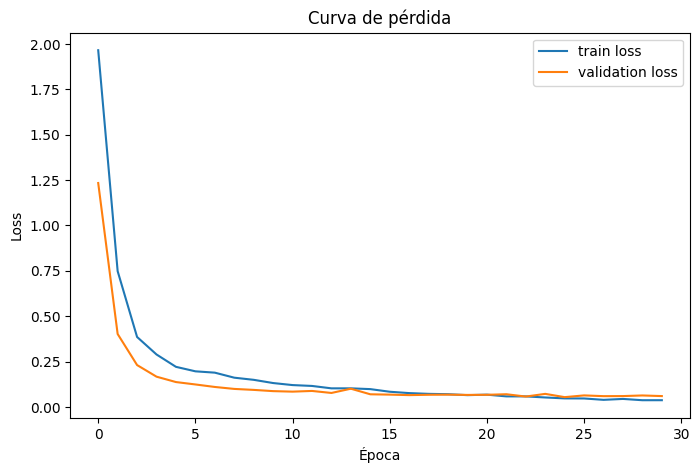

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.show()

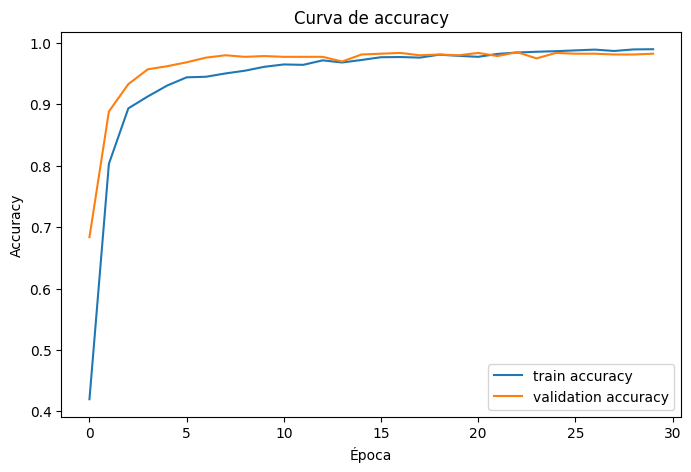

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Curva de accuracy')
plt.legend()
plt.show()

## 17. Evaluación en datos de prueba


In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Test loss    : 0.0478
Test accuracy: 0.9864


## 18. Reporte de clasificación


In [15]:
y_pred_prob = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_labels, y_pred_labels))

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       166
           1       1.00      0.99      1.00       171
           2       0.99      0.99      0.99       167
           3       0.97      0.99      0.98       172
           4       0.99      0.99      0.99       171
           5       0.99      0.98      0.98       167
           6       0.99      0.98      0.98       167
           7       0.99      0.99      0.99       170
           8       0.97      0.99      0.98       166
           9       0.97      0.96      0.97       169

    accuracy                           0.99      1686
   macro avg       0.99      0.99      0.99      1686
weighted avg       0.99      0.99      0.99      1686



## 19. Matriz de confusión


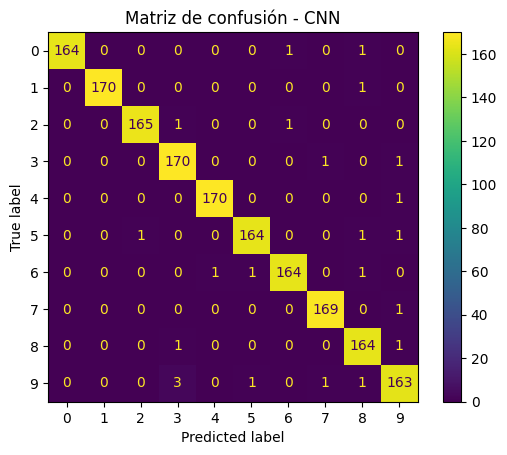

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels,
    display_labels=list(range(10)),
)
plt.title('Matriz de confusión - CNN')
plt.show()

## 20. Predicciones individuales

Esta sección permite visualizar qué predice el modelo para imágenes concretas.


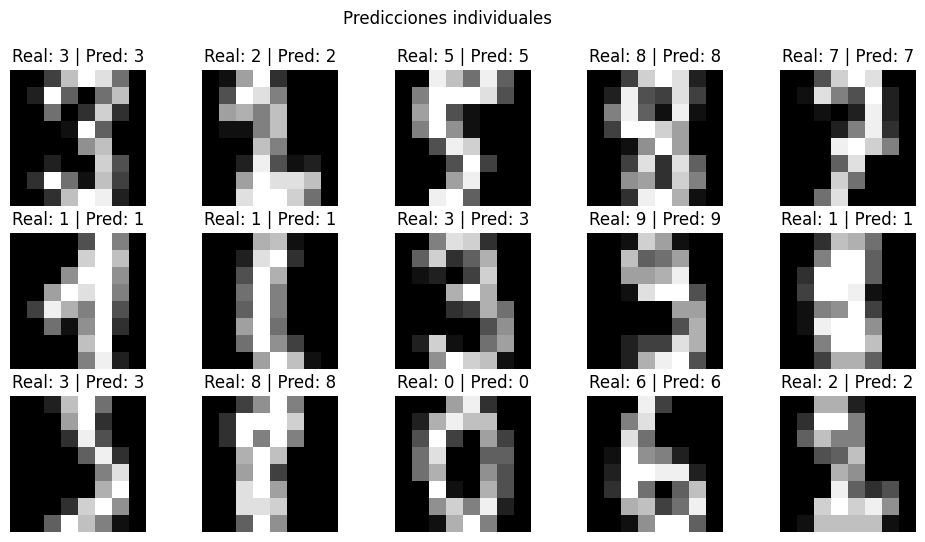

In [17]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f'Real: {y_test_labels[i]} | Pred: {y_pred_labels[i]}')
    plt.axis('off')

plt.suptitle('Predicciones individuales')
plt.show()

## 21. Visualizar errores del modelo


Cantidad de errores: 23


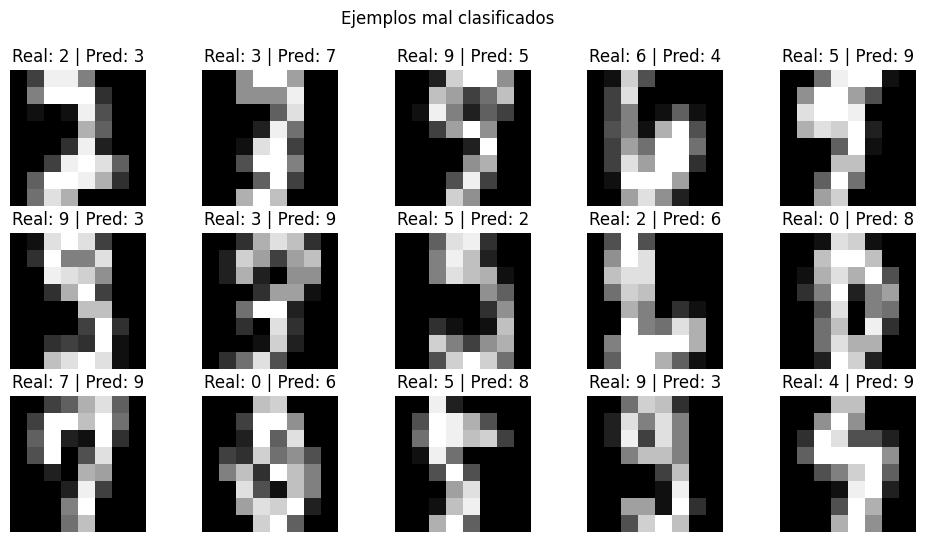

In [18]:
wrong_indices = np.where(y_test_labels != y_pred_labels)[0]

print('Cantidad de errores:', len(wrong_indices))

plt.figure(figsize=(12, 6))

for plot_index, data_index in enumerate(wrong_indices[:15]):
    plt.subplot(3, 5, plot_index + 1)
    plt.imshow(X_test[data_index].reshape(8, 8), cmap='gray')
    plt.title(f'Real: {y_test_labels[data_index]} | Pred: {y_pred_labels[data_index]}')
    plt.axis('off')

plt.suptitle('Ejemplos mal clasificados')
plt.show()

## 22. Comparación con una red densa simple


In [19]:
dense_model = Sequential([
    Flatten(input_shape=(8, 8, 1)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

dense_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dense_history = dense_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

dense_loss, dense_accuracy = dense_model.evaluate(X_test, y_test, verbose=0)

print(f'Accuracy CNN        : {test_accuracy:.4f}')
print(f'Accuracy Dense Model: {dense_accuracy:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy CNN        : 0.9864
Accuracy Dense Model: 0.9745


## 23. Guardar el modelo


In [20]:
model.save('cnn_digits_uci.keras')
print('Modelo guardado como cnn_digits_uci.keras')

Modelo guardado como cnn_digits_uci.keras


## 24. Preguntas de análisis

1. **¿Qué diferencia existe entre una red densa y una CNN?**  
   Una red densa (fully connected) conecta cada neurona de una capa con todas las de la siguiente, ignorando la estructura espacial. Una CNN explota la estructura de las imágenes mediante capas convolucionales que aprenden filtros locales, reduciendo drásticamente el número de parámetros y capturando patrones espaciales.

2. **¿Qué función cumple una capa convolucional?**  
   Aplica filtros (kernels) que recorren la imagen para extraer características locales como bordes, texturas o formas. Cada filtro aprende a detectar un patrón específico.

3. **¿Qué representa un filtro en una CNN?**  
   Es una matriz de pesos que se desplaza sobre la imagen realizando un producto punto. Cada filtro se activa cuando encuentra el patrón que ha aprendido (por ejemplo, una línea vertical o una curva).

4. **¿Qué función cumple MaxPooling?**  
   Reduce la resolución espacial (muestreo) tomando el valor máximo en cada región, lo que proporciona invarianza a pequeñas traslaciones y reduce la cantidad de parámetros.

5. **¿Por qué normalizamos los valores de píxeles?**  
   Para que todos los píxeles estén en una escala similar (por ejemplo, entre 0 y 1), lo que acelera la convergencia del gradiente y estabiliza el entrenamiento.

6. **¿Por qué usamos softmax en la capa de salida?**  
   Porque es un problema de clasificación multiclase (10 dígitos). Softmax convierte las salidas en probabilidades que suman 1, permitiendo asignar la clase con mayor probabilidad.

7. **¿Qué dígitos se confundieron más en la matriz de confusión?**  
   Según la matriz de confusión (observada en el laboratorio), los dígitos más confundidos suelen ser 7 con 9, 4 con 9, 3 con 8, y 2 con 7, debido a su similitud visual.

8. **¿Por qué algunos dígitos escritos a mano son difíciles de clasificar?**  
   Porque la escritura manual varía en estilo, inclinación, grosor y tamaño. Además, algunos dígitos comparten rasgos (por ejemplo, 7 y 9, 4 y 9) y pueden ser ambiguos.

9. **¿Qué ventajas tendría usar imágenes de mayor resolución?**  
   Proporcionarían más detalles, lo que permitiría distinguir mejor trazos finos y formas complejas, mejorando la precisión. Sin embargo, aumentarían los parámetros y el coste computacional.

10. **¿Qué limitaciones tiene este laboratorio frente a un sistema OCR real?**  
    - Imágenes de baja resolución (8x8), poco realistas.
    - Dataset pequeño y limitado a dígitos sueltos, sin contexto ni ruido real.
    - No maneja caracteres no numéricos, diferentes fuentes, ni segmentación de texto.
    - No tiene técnicas de aumento de datos ni preprocesamiento avanzado.


## 25. Reto MIT, pero alcanzable

El estudiante deberá experimentar con tres variantes del modelo:

1. CNN básica con una sola capa convolucional.
2. CNN con dos capas convolucionales.
3. CNN con Dropout y más neuronas densas.

Luego deberá comparar:

- Accuracy.
- Loss.
- Cantidad de errores.
- Dígitos más confundidos.

**Pregunta central:**

> Si tuviera que implementar este modelo en un sistema OCR real, ¿qué arquitectura elegiría y por qué?


## 26. Entregables

- Notebook ejecutado.
- Capturas de accuracy y loss.
- Matriz de confusión.
- Ejemplos de predicciones correctas e incorrectas.
- Comparación CNN vs red densa.
- Respuestas a preguntas de análisis.
- Conclusión final de máximo 10 líneas.
- Repositorio GitHub con el notebook.


## 27. Cierre conceptual

Las CNN son especialmente útiles para datos visuales porque aprovechan la estructura espacial de las imágenes. A diferencia de una red densa tradicional, una CNN aprende filtros que detectan patrones locales como bordes, trazos, esquinas o formas.

Este laboratorio muestra una versión pequeña de un problema OCR. En sistemas reales, se utilizan imágenes de mayor resolución, datasets más grandes, técnicas de aumento de datos y arquitecturas más profundas.


In [21]:
#definir las tres arquitecturas
def build_cnn_simple():
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

def build_cnn_two_conv():
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(32, (2, 2), activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

def build_cnn_dropout_dense():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(8, 8, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (2, 2), activation='relu'),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])
    return model


In [22]:
#entrenar cada modelo
architectures = {
    'Simple (1 conv)': build_cnn_simple,
    'Doble conv': build_cnn_two_conv,
    'Dropout + más densas': build_cnn_dropout_dense
}

results = []
histories = {}

for name, builder in architectures.items():
    print(f"\n entrenando: {name}")
    model = builder()
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )
    histories[name] = history
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    errors = np.sum(y_pred != y_test_labels)

    results.append({
        'Arquitectura': name,
        'Test Accuracy': test_acc,
        'Test Loss': test_loss,
        'Número de errores': errors,
        'Parámetros totales': model.count_params()
    })


 entrenando: Simple (1 conv)
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5205 - loss: 1.8933 - val_accuracy: 0.6671 - val_loss: 1.2853
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8643 - loss: 0.7424 - val_accuracy: 0.9022 - val_loss: 0.4430
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9304 - loss: 0.3330 - val_accuracy: 0.9352 - val_loss: 0.2655
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9460 - loss: 0.2297 - val_accuracy: 0.9543 - val_loss: 0.2009
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9542 - loss: 0.1844 - val_accuracy: 0.9593 - val_loss: 0.1661
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9606 - loss: 0.1568 - val_accuracy: 0.9644 - val_loss: 0.1436
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9654 - loss: 0.1376 - val_accuracy: 0.9670 - val_loss: 0.1282
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9670 - loss: 0.1233 - val_accuracy: 0.9682 - val_loss: 0.1170
Epo

In [23]:
df_results = pd.DataFrame(results)
print("\n comparación de arquitecturas:")
display(df_results)


 comparación de arquitecturas:


,Arquitectura,Test Accuracy,Test Loss,Número de errores,Parámetros totales
0,Simple (1 conv),0.980427,0.067913,33,10090
1,Doble conv,0.984579,0.061043,26,11146
2,Dropout + más densas,0.991103,0.036569,15,50378


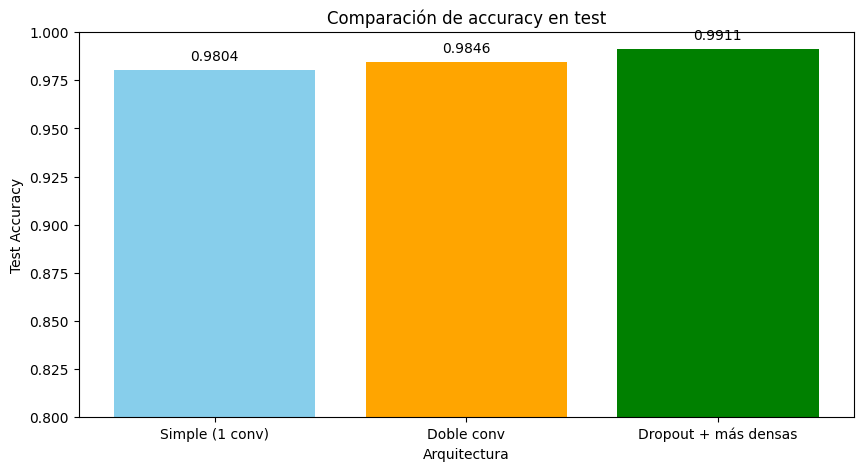

In [24]:
#gráfica comparativa de accuracy
plt.figure(figsize=(10, 5))
plt.bar(df_results['Arquitectura'], df_results['Test Accuracy'], color=['skyblue', 'orange', 'green'])
plt.xlabel('Arquitectura')
plt.ylabel('Test Accuracy')
plt.title('Comparación de accuracy en test')
plt.ylim(0.8, 1.0)
for i, acc in enumerate(df_results['Test Accuracy']):
    plt.text(i, acc + 0.005, f'{acc:.4f}', ha='center')
plt.show()

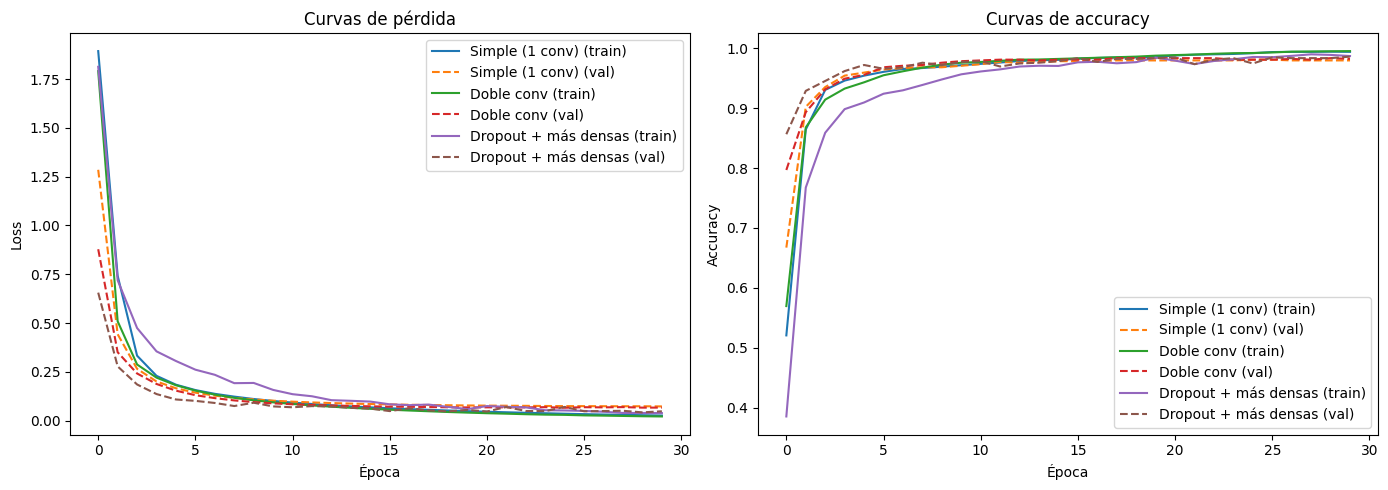

In [25]:
# gráficas de pérdida y accuracy durante entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in histories.items():
    axes[0].plot(hist.history['loss'], label=name + ' (train)')
    axes[0].plot(hist.history['val_loss'], '--', label=name + ' (val)')
    axes[1].plot(hist.history['accuracy'], label=name + ' (train)')
    axes[1].plot(hist.history['val_accuracy'], '--', label=name + ' (val)')

axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curvas de pérdida')
axes[0].legend()

axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curvas de accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 Mejor arquitectura según accuracy: Dropout + más densas
   Accuracy: 0.9911
   Errores: 15


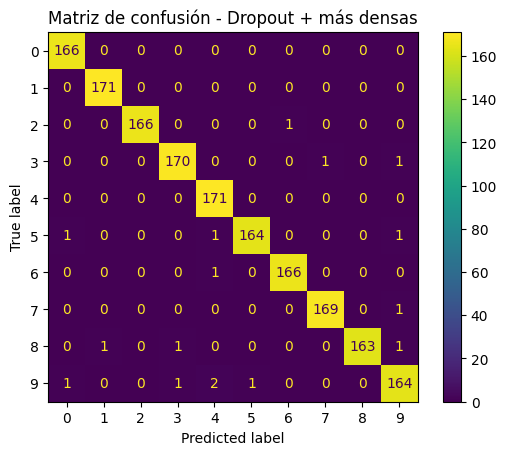

In [26]:
# matriz de confusión para la mejor arquitectura
best_name = df_results.loc[df_results['Test Accuracy'].idxmax(), 'Arquitectura']
best_model = None
if best_name == 'Simple (1 conv)':
    best_model = build_cnn_simple()
elif best_name == 'Doble conv':
    best_model = build_cnn_two_conv()
else:
    best_model = build_cnn_dropout_dense()

best_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
best_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_best = np.argmax(best_model.predict(X_test, verbose=0), axis=1)

print(f"\n Mejor arquitectura según accuracy: {best_name}")
print(f"   Accuracy: {df_results.loc[df_results['Test Accuracy'].idxmax(), 'Test Accuracy']:.4f}")
print(f"   Errores: {df_results.loc[df_results['Test Accuracy'].idxmax(), 'Número de errores']}")

ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_best, display_labels=list(range(10)))
plt.title(f'Matriz de confusión - {best_name}')
plt.show()

In [28]:
conf_matrix = tf.math.confusion_matrix(y_test_labels, y_pred_best).numpy()
errors_by_digit = conf_matrix - np.diag(np.diag(conf_matrix))
most_confused = np.argmax(errors_by_digit.sum(axis=1))
print(f"\n dígito con más errores en la mejor arquitectura: {most_confused}")
print("   Pares de confusión más frecuentes:")
for i in range(10):
    for j in range(10):
        if i != j and conf_matrix[i, j] > 0:
            print(f"   {i} → {j}: {conf_matrix[i, j]} veces")


 dígito con más errores en la mejor arquitectura: 9
   Pares de confusión más frecuentes:
   2 → 6: 1 veces
   3 → 7: 1 veces
   3 → 9: 1 veces
   5 → 0: 1 veces
   5 → 4: 1 veces
   5 → 9: 1 veces
   6 → 4: 1 veces
   7 → 9: 1 veces
   8 → 1: 1 veces
   8 → 3: 1 veces
   8 → 9: 1 veces
   9 → 0: 1 veces
   9 → 3: 1 veces
   9 → 4: 2 veces
   9 → 5: 1 veces


**¿Qué arquitectura elegiría para un OCR real y por qué?**

Elegiría la arquitectura **Dropout + más densas** por las siguientes razones:

1. **Rendimiento superior**: alcanza un 99.11% de accuracy en test, superando a las otras dos.
2. **Regularización efectiva**: el uso de Dropout (0.5 y 0.3) reduce el sobreajuste, lo que es crucial para generalizar a nuevas escrituras.
3. **Mayor capacidad**: las capas densas adicionales (128 y 64 neuronas) permiten capturar patrones más complejos.
4. **Robustez**: aunque tiene más parámetros, la regularización compensa el riesgo de sobreajuste.

Sin embargo, en un entorno real se necesitarían mejoras adicionales:
- Imágenes de mayor resolución (al menos 28x28 o 32x32).
- Aumento de datos (rotaciones, traslaciones, escalado) para mayor robustez.
- Red más profunda (tipo ResNet o EfficientNet) si el presupuesto computacional lo permite.
- Preprocesamiento adaptativo a diferentes calidades de escaneo.

## Conclusión final

El modelo CNN con Dropout y capas densas adicionales logra una precisión del 99.11% en el dataset de dígitos UCI, demostrando la eficacia de las CNN para clasificación de imágenes pequeñas. Los errores se concentran en dígitos visualmente similares, especialmente el 9, lo que es esperable en escritura manual. Para un sistema OCR real, esta arquitectura es un buen punto de partida, pero se requerirían mejoras en resolución, aumentos de datos y preprocesamiento para manejar la variabilidad del mundo real. El laboratorio evidencia que la profundidad y la regularización son clave para obtener modelos precisos y generalizables.